# Deep Learning Model Training
## Plastic Waste Classification

**Models**: ResNet18, ResNet50, MobileNetV2

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
from PIL import Image
import time
import copy
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 1. Load Data

In [9]:
import re

DATASET_PATH = r'c:\Users\vimal\OneDrive\Desktop\FINAL AIML\Waste segregation.v1i.multiclass'
TRAIN_DIR = os.path.join(DATASET_PATH, 'train')
TEST_DIR = os.path.join(DATASET_PATH, 'test')
VALID_DIR = os.path.join(DATASET_PATH, 'valid')

train_csv = pd.read_csv(os.path.join(TRAIN_DIR, '_classes.csv'))
test_csv = pd.read_csv(os.path.join(TEST_DIR, '_classes.csv'))
valid_csv = pd.read_csv(os.path.join(VALID_DIR, '_classes.csv'))

def extract_plastic_type(filename):
    match = re.match(r'^([A-Z]+)', filename)
    if match and match.group(1) in ['HDPE','LDPE','PET','PP','PS','PVC','OTHERS']:
        return match.group(1)
    return 'UNKNOWN'

train_csv['plastic_type'] = train_csv['filename'].apply(extract_plastic_type)
test_csv['plastic_type'] = test_csv['filename'].apply(extract_plastic_type)
valid_csv['plastic_type'] = valid_csv['filename'].apply(extract_plastic_type)

train_csv = train_csv[train_csv['plastic_type'] != 'UNKNOWN'].reset_index(drop=True)
test_csv = test_csv[test_csv['plastic_type'] != 'UNKNOWN'].reset_index(drop=True)
valid_csv = valid_csv[valid_csv['plastic_type'] != 'UNKNOWN'].reset_index(drop=True)

plastic_types = sorted(train_csv['plastic_type'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(plastic_types)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

train_csv['label'] = train_csv['plastic_type'].map(class_to_idx)
test_csv['label'] = test_csv['plastic_type'].map(class_to_idx)
valid_csv['label'] = valid_csv['plastic_type'].map(class_to_idx)

num_classes = len(plastic_types)
print(f'Classes: {plastic_types}\nNum classes: {num_classes}')

Classes: ['HDPE', 'LDPE', 'OTHERS', 'PET', 'PP', 'PS']
Num classes: 6


## 2. Data Preparation

In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 0.001

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

class PlasticDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = csv_file.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), 'white')
        if self.transform:
            image = self.transform(image)
        return image, row['label']

train_dataset = PlasticDataset(train_csv, TRAIN_DIR, train_transforms)
valid_dataset = PlasticDataset(valid_csv, VALID_DIR, val_transforms)
test_dataset = PlasticDataset(test_csv, TEST_DIR, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_loader)} batches\nValid: {len(valid_loader)} batches\nTest: {len(test_loader)} batches')

Train: 184 batches
Valid: 47 batches
Test: 24 batches


## 3. Model Architectures

In [11]:
def create_resnet18(num_classes):
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def create_resnet50(num_classes):
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def create_mobilenetv2(num_classes):
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

print('Models: ResNet18, ResNet50, MobileNetV2')

Models: ResNet18, ResNet50, MobileNetV2


## 4. Training Function

In [12]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, num_epochs, model_name):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    patience = 5
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    start_time = time.time()
    
    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in tqdm(train_loader, desc='Train'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(valid_loader, desc='Valid'):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
        
        val_loss = val_loss / len(valid_loader.dataset)
        val_acc = val_corrects.double() / len(valid_loader.dataset)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())
        
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
        scheduler.step(val_loss)
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f'✓ Best: {val_acc:.4f}')
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    time_elapsed = time.time() - start_time
    print(f'\nTime: {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
    print(f'Best Val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history, best_acc.item(), time_elapsed

print('Training function ready')

Training function ready


## 5. Train Models

In [13]:
results = {}
criterion = nn.CrossEntropyLoss()
print('Starting training...')

Starting training...


In [14]:
print('\n### ResNet18 ###')
model_r18 = create_resnet18(num_classes).to(device)
opt = optim.Adam(model_r18.parameters(), lr=LR)
sch = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', patience=3, factor=0.5)
model_r18, hist_r18, acc_r18, time_r18 = train_model(model_r18, train_loader, valid_loader, criterion, opt, sch, NUM_EPOCHS, 'ResNet18')
results['ResNet18'] = {'model': model_r18, 'history': hist_r18, 'best_acc': acc_r18, 'time': time_r18}


### ResNet18 ###

Epoch 1/10


Valid: 100%|██████████| 47/47 [01:16<00:00,  1.62s/it]


Train Loss: 0.2981 Acc: 0.9042
Val Loss: 0.0968 Acc: 0.9705
✓ Best: 0.9705

Epoch 2/10


Valid: 100%|██████████| 47/47 [00:48<00:00,  1.03s/it]


Train Loss: 0.1715 Acc: 0.9448
Val Loss: 0.2699 Acc: 0.9094

Epoch 3/10


...

Train Loss: 0.0194 Acc: 0.9927
Val Loss: 0.0229 Acc: 0.9913

Epoch 9/10


Valid: 100%|██████████| 47/47 [00:51<00:00,  1.10s/it]


Train Loss: 0.0402 Acc: 0.9855
Val Loss: 0.0696 Acc: 0.9819

Epoch 10/10


Valid: 100%|██████████| 47/47 [00:51<00:00,  1.09s/it]

Train Loss: 0.0278 Acc: 0.9894
Val Loss: 0.0240 Acc: 0.9926

Time: 101m 25s
Best Val Acc: 0.9953


In [16]:
print('\n### MobileNetV2 ###')
model_mob = create_mobilenetv2(num_classes).to(device)
opt = optim.Adam(model_mob.parameters(), lr=LR)
sch = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', patience=3, factor=0.5)
model_mob, hist_mob, acc_mob, time_mob = train_model(model_mob, train_loader, valid_loader, criterion, opt, sch, NUM_EPOCHS, 'MobileNetV2')
results['MobileNetV2'] = {'model': model_mob, 'history': hist_mob, 'best_acc': acc_mob, 'time': time_mob}


### MobileNetV2 ###
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\vimal/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 24.1MB/s]



Epoch 1/10


Valid: 100%|██████████| 47/47 [01:13<00:00,  1.56s/it]


Train Loss: 0.2624 Acc: 0.9165
Val Loss: 0.1049 Acc: 0.9698
✓ Best: 0.9698

Epoch 2/10


Valid: 100%|██████████| 47/47 [01:15<00:00,  1.60s/it]


Train Loss: 0.1191 Acc: 0.9617
Val Loss: 0.0392 Acc: 0.9859
✓ Best: 0.9859

Epoch 3/10


Train:  75%|███████▌  | 138/184 [18:40<06:13,  8.12s/it]


KeyboardInterrupt: 

## 6. Model Comparison

In [17]:
comp_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Val Accuracy': [results[m]['best_acc'] for m in results.keys ()],
    'Time (min)': [results[m]['time']/60 for m in results.keys()]
}).sort_values('Val Accuracy', ascending=False)

print('='*60)
print('MODEL COMPARISON')
print('='*60)
print(comp_df.to_string(index=False))
print('='*60)
best_model_name = comp_df.iloc[0]['Model']
print(f'\n🏆 Best: {best_model_name} ({comp_df.iloc[0]["Val Accuracy"]:.4f})')

MODEL COMPARISON
   Model  Val Accuracy  Time (min)
ResNet18      0.995302   101.41331

🏆 Best: ResNet18 (0.9953)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, (name, data) in enumerate(results.items()):
    h = data['history']
    axes[0, idx].plot(h['train_loss'], label='Train', linewidth=2)
    axes[0, idx].plot(h['val_loss'], label='Val', linewidth=2)
    axes[0, idx].set_title(f'{name} - Loss', fontweight='bold')
    axes[0, idx].legend()
    axes[0, idx].grid(alpha=0.3)
    axes[1, idx].plot(h['train_acc'], label='Train', linewidth=2)
    axes[1, idx].plot(h['val_acc'], label='Val', linewidth=2)
    axes[1, idx].set_title(f'{name} - Accuracy', fontweight='bold')
    axes[1, idx].legend()
    axes[1, idx].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=300)
plt.show()

## 7. Test Evaluation

In [18]:
def evaluate(model, test_loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for inputs, lbls in tqdm(test_loader, desc='Test'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, pred = torch.max(outputs, 1)
            preds.extend(pred.cpu().numpy())
            labels.extend(lbls.numpy())
    return preds, labels

test_results = {}
for name, data in results.items():
    print(f'\nEvaluating {name}...')
    preds, labels = evaluate(data['model'], test_loader)
    report = classification_report(labels, preds, target_names=plastic_types)
    cm = confusion_matrix(labels, preds)
    test_results[name] = {'preds': preds, 'labels': labels, 'report': report, 'cm': cm}
    print(report)


Evaluating ResNet18...


Test: 100%|██████████| 24/24 [00:46<00:00,  1.93s/it]

              precision    recall  f1-score   support

        HDPE       0.99      1.00      1.00       134
        LDPE       1.00      1.00      1.00        78
      OTHERS       0.99      0.99      0.99       228
         PET       0.99      0.99      0.99       225
          PP       0.96      0.96      0.96        67
          PS       1.00      0.97      0.99        34

    accuracy                           0.99       766
   macro avg       0.99      0.98      0.99       766
weighted avg       0.99      0.99      0.99       766



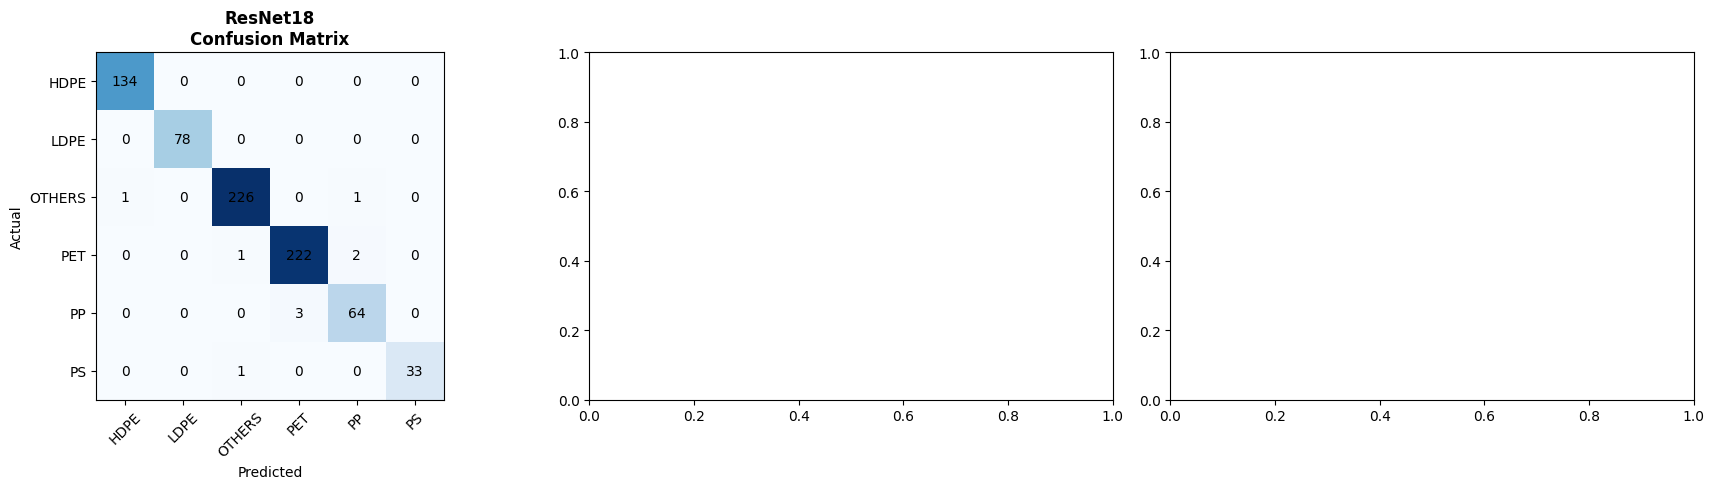

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, data) in enumerate(test_results.items()):
    cm = data['cm']
    im = axes[idx].imshow(cm, cmap='Blues')
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticks(range(num_classes))
    axes[idx].set_yticks(range(num_classes))
    axes[idx].set_xticklabels(plastic_types, rotation=45)
    axes[idx].set_yticklabels(plastic_types)
    for i in range(num_classes):
        for j in range(num_classes):
            axes[idx].text(j, i, cm[i,j], ha='center', va='center')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

## 8. Save Best Model

In [20]:
best_model = results[best_model_name]['model']
model_path = f'best_model_{best_model_name}.pth'
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_name': best_model_name,
    'class_to_idx': class_to_idx,
    'idx_to_class': idx_to_class,
    'plastic_types': plastic_types,
    'num_classes': num_classes,
    'img_size': IMG_SIZE,
    'best_acc': results[best_model_name]['best_acc']
}, model_path)
print(f'✅ Best model saved: {model_path}')

✅ Best model saved: best_model_ResNet18.pth


## 9. Summary

In [ ]:
print('='*70)
print('TRAINING COMPLETE')
print('='*70)
print(f'\nBest Model: {best_model_name}')
print(f'Validation Accuracy: {results[best_model_name]["best_acc"]:.4f}')
print(f'Training Time: {results[best_model_name]["time"]/60:.1f} minutes')
print(f'\nModel saved: {model_path}')
print('\n✅ Ready for deployment!')

TRAINING COMPLETE

Best Model: ResNet18
Validation Accuracy: 0.9953
Training Time: 101.4 minutes

Model saved: best_model_ResNet18.pth

✅ Ready for deployment!


: 